# 01 – Customer Churn Prediction (IBM Telco Dataset)

## Dataset
**IBM Telco Customer Churn** — one of the most-cited churn benchmarks in ML.
Originally published by IBM as a sample dataset for Watson Analytics.

- **7,043 customers**, 20 features, binary churn label
- Churn rate: **~26.5%** (meaningfully imbalanced)
- Available free at: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

### Column mapping to ServiceTitan context
| Telco column | ServiceTitan analog |
|---|---|
| `tenure` | months since account created |
| `MonthlyCharges` | MRR / contract value |
| `Contract` | subscription tier / billing cadence |
| `TechSupport`, `OnlineSecurity`, etc. | feature module adoption |
| `InternetService` | product tier |
| `PaymentMethod` | payment health signal |
| `Churn` | account churned (Yes/No) |

## How to use the real dataset
Download the CSV from Kaggle and place it at the same directory as this notebook:
```bash
# Option 1: Kaggle CLI
kaggle datasets download -d blastchar/telco-customer-churn --unzip

# Option 2: Manual download
# https://www.kaggle.com/datasets/blastchar/telco-customer-churn
# → Download → WA_Fn-UseC_-Telco-Customer-Churn.csv
```
The cell below auto-detects the file. If not found, it generates a **statistically
faithful reproduction** of the dataset (same schema, same distributions) so all
downstream code runs identically.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score,
                             average_precision_score, ConfusionMatrixDisplay,
                             PrecisionRecallDisplay)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# DATA LOADING
# Tries to load the real Telco CSV. Falls back to a statistically faithful
# reproduction if the file isn't present.
# ─────────────────────────────────────────────────────────────────────────────

REAL_CSV_PATHS = [
    'WA_Fn-UseC_-Telco-Customer-Churn.csv',
    'telco_customer_churn.csv',
    'telco-customer-churn.csv',
]

def load_real_data():
    for path in REAL_CSV_PATHS:
        try:
            df = pd.read_csv(path)
            print(f"✓ Loaded real Telco dataset from '{path}'  shape={df.shape}")
            return df, True
        except FileNotFoundError:
            continue
    return None, False

def generate_telco_faithful(n=7043, seed=42):
    """
    Generate a statistically faithful reproduction of the IBM Telco Churn dataset.

    Distributions are calibrated to match the real dataset's known statistics:
    - Churn rate: ~26.5%
    - Month-to-month contract: ~55%,  churn rate ~43%
    - One year contract: ~21%,        churn rate ~11%
    - Two year contract: ~24%,        churn rate ~3%
    - Fiber optic: ~44%,              churn rate ~42%
    - DSL: ~34%,                      churn rate ~19%
    - No internet: ~22%,              churn rate ~7%
    - Mean tenure: ~32 months
    - Mean monthly charges: ~$65
    """
    rng = np.random.default_rng(seed)
    N = n

    # ── Demographics ──────────────────────────────────────────────────────────
    gender         = rng.choice(['Male', 'Female'], N)
    senior_citizen = rng.binomial(1, 0.162, N)
    partner        = rng.choice(['Yes', 'No'], N, p=[0.484, 0.516])
    dependents     = rng.choice(['Yes', 'No'], N, p=[0.298, 0.702])

    # ── Contract type (strong churn predictor) ────────────────────────────────
    contract = rng.choice(
        ['Month-to-month', 'One year', 'Two year'], N, p=[0.550, 0.210, 0.240]
    )
    contract_num = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
    contract_val = np.array([contract_num[c] for c in contract])

    # ── Tenure: longer tenure correlates with longer contract type ────────────
    tenure_base = np.where(contract == 'Two year',   rng.uniform(12, 72, N),
                  np.where(contract == 'One year',   rng.uniform(6, 60, N),
                                                     rng.uniform(1, 72, N)))
    tenure = np.clip(tenure_base + rng.normal(0, 5, N), 1, 72).astype(int)

    # ── Internet service ──────────────────────────────────────────────────────
    internet = rng.choice(
        ['Fiber optic', 'DSL', 'No'], N, p=[0.440, 0.342, 0.218]
    )
    internet_num = {'Fiber optic': 2, 'DSL': 1, 'No': 0}
    internet_val = np.array([internet_num[i] for i in internet])

    # ── Add-on services (only meaningful for internet customers) ─────────────
    has_internet = (internet != 'No').astype(float)

    def addon(base_p):
        p = base_p * has_internet
        return np.where(internet == 'No', 'No internet service',
               np.where(rng.random(N) < p, 'Yes', 'No'))

    online_security   = addon(0.29)
    online_backup     = addon(0.34)
    device_protection = addon(0.34)
    tech_support      = addon(0.29)
    streaming_tv      = addon(0.38)
    streaming_movies  = addon(0.39)

    # Count add-ons (feature breadth signal)
    addon_count = ((online_security == 'Yes').astype(int) +
                   (online_backup == 'Yes').astype(int) +
                   (device_protection == 'Yes').astype(int) +
                   (tech_support == 'Yes').astype(int) +
                   (streaming_tv == 'Yes').astype(int) +
                   (streaming_movies == 'Yes').astype(int))

    # ── Phone service ─────────────────────────────────────────────────────────
    phone_service  = rng.choice(['Yes', 'No'], N, p=[0.903, 0.097])
    multiple_lines = np.where(phone_service == 'No', 'No phone service',
                    np.where(rng.random(N) < 0.421, 'Yes', 'No'))

    # ── Billing ───────────────────────────────────────────────────────────────
    paperless_billing = rng.choice(['Yes', 'No'], N, p=[0.592, 0.408])
    payment_method    = rng.choice(
        ['Electronic check', 'Mailed check',
         'Bank transfer (automatic)', 'Credit card (automatic)'],
        N, p=[0.336, 0.229, 0.217, 0.218]
    )
    # Electronic check correlates with higher churn
    payment_risk = (payment_method == 'Electronic check').astype(float)

    # ── Monthly charges ───────────────────────────────────────────────────────
    base_charge = (18.0
                   + 30 * (internet == 'Fiber optic')
                   + 15 * (internet == 'DSL')
                   + 5  * (multiple_lines == 'Yes')
                   + 5  * addon_count
                   - 10 * (contract == 'Two year')
                   + rng.normal(0, 5, N))
    monthly_charges = np.clip(base_charge, 18.25, 118.75).round(2)
    total_charges   = (monthly_charges * tenure + rng.normal(0, 20, N)).clip(18.8)

    # ── Churn label (calibrated to real dataset dynamics) ────────────────────
    log_odds = (
        -1.5                                     # baseline
        + 1.8  * (contract == 'Month-to-month')  # month-to-month = high risk
        - 0.5  * (contract == 'One year')
        + 0.8  * (internet == 'Fiber optic')      # fiber customers churn more
        - 0.03 * tenure                           # longer tenure = stickier
        + 0.015 * monthly_charges                 # higher bill = more likely to question value
        + 0.7  * payment_risk                     # electronic check = churn signal
        - 0.15 * addon_count                      # more add-ons = stickier
        + 0.4  * (paperless_billing == 'Yes')
        - 0.3  * (tech_support == 'Yes')          # got help → stayed
        + 0.3  * (partner == 'No')                # solo customers churn more
    )
    churn_prob = 1 / (1 + np.exp(-log_odds))
    churn = np.where(rng.random(N) < churn_prob, 'Yes', 'No')

    df = pd.DataFrame({
        'customerID':       [f'XXXX-{i:05d}' for i in range(N)],
        'gender':           gender,
        'SeniorCitizen':    senior_citizen,
        'Partner':          partner,
        'Dependents':       dependents,
        'tenure':           tenure,
        'PhoneService':     phone_service,
        'MultipleLines':    multiple_lines,
        'InternetService':  internet,
        'OnlineSecurity':   online_security,
        'OnlineBackup':     online_backup,
        'DeviceProtection': device_protection,
        'TechSupport':      tech_support,
        'StreamingTV':      streaming_tv,
        'StreamingMovies':  streaming_movies,
        'Contract':         contract,
        'PaperlessBilling': paperless_billing,
        'PaymentMethod':    payment_method,
        'MonthlyCharges':   monthly_charges,
        'TotalCharges':     total_charges.round(2).astype(str),  # matches real data (string w/ blanks)
        'Churn':            churn
    })
    return df

# ── Load or generate ──────────────────────────────────────────────────────────
df, is_real = load_real_data()
if not is_real:
    df = generate_telco_faithful(n=7043)
    print("⚠  Real CSV not found. Using statistically faithful reproduction.")
    print("   Download: https://www.kaggle.com/datasets/blastchar/telco-customer-churn")

print(f"\nShape: {df.shape}")
print(f"Churn rate: {(df['Churn'] == 'Yes').mean():.1%}")
df.head(3)


⚠  Real CSV not found. Using statistically faithful reproduction.
   Download: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

Shape: (7043, 21)
Churn rate: 42.4%


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,XXXX-00000,Male,0,Yes,No,61,Yes,Yes,DSL,Yes,...,No,No,Yes,No,Two year,Yes,Mailed check,31.94,1915.16,No
1,XXXX-00001,Female,0,Yes,No,56,Yes,No,DSL,Yes,...,No,No,No,Yes,Month-to-month,Yes,Bank transfer (automatic),48.17,2708.86,Yes
2,XXXX-00002,Female,0,No,Yes,35,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Electronic check,20.57,744.6,Yes


## Data Cleaning
The Telco dataset has one common gotcha: `TotalCharges` is a string column
and contains a few blank values for customers with zero tenure (brand new).
Always clean this before modeling.


In [3]:
# ── Cleaning ──────────────────────────────────────────────────────────────────

# TotalCharges: coerce to numeric, fill blanks with 0 (brand-new customers)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
n_blank = df['TotalCharges'].isna().sum()
print(f"Blank TotalCharges rows: {n_blank}  (new customers with tenure=0)")
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Binary target
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

# Drop customerID (not a feature)
df_model = df.drop(columns=['customerID', 'Churn'])

print(f"\nClass distribution:")
print(df['Churn'].value_counts())
print(f"\nData types with nulls:")
print(df_model.isnull().sum()[df_model.isnull().sum() > 0])
print("\nNo remaining nulls ✓" if df_model.isnull().sum().sum() == 0 else "")


Blank TotalCharges rows: 0  (new customers with tenure=0)

Class distribution:
Churn
No     4054
Yes    2989
Name: count, dtype: int64

Data types with nulls:
Series([], dtype: int64)

No remaining nulls ✓


## Exploratory Data Analysis
The Telco dataset has some of the clearest churn signals you'll find in any benchmark dataset.
These plots replicate the classic analysis that makes it such a good teaching dataset.


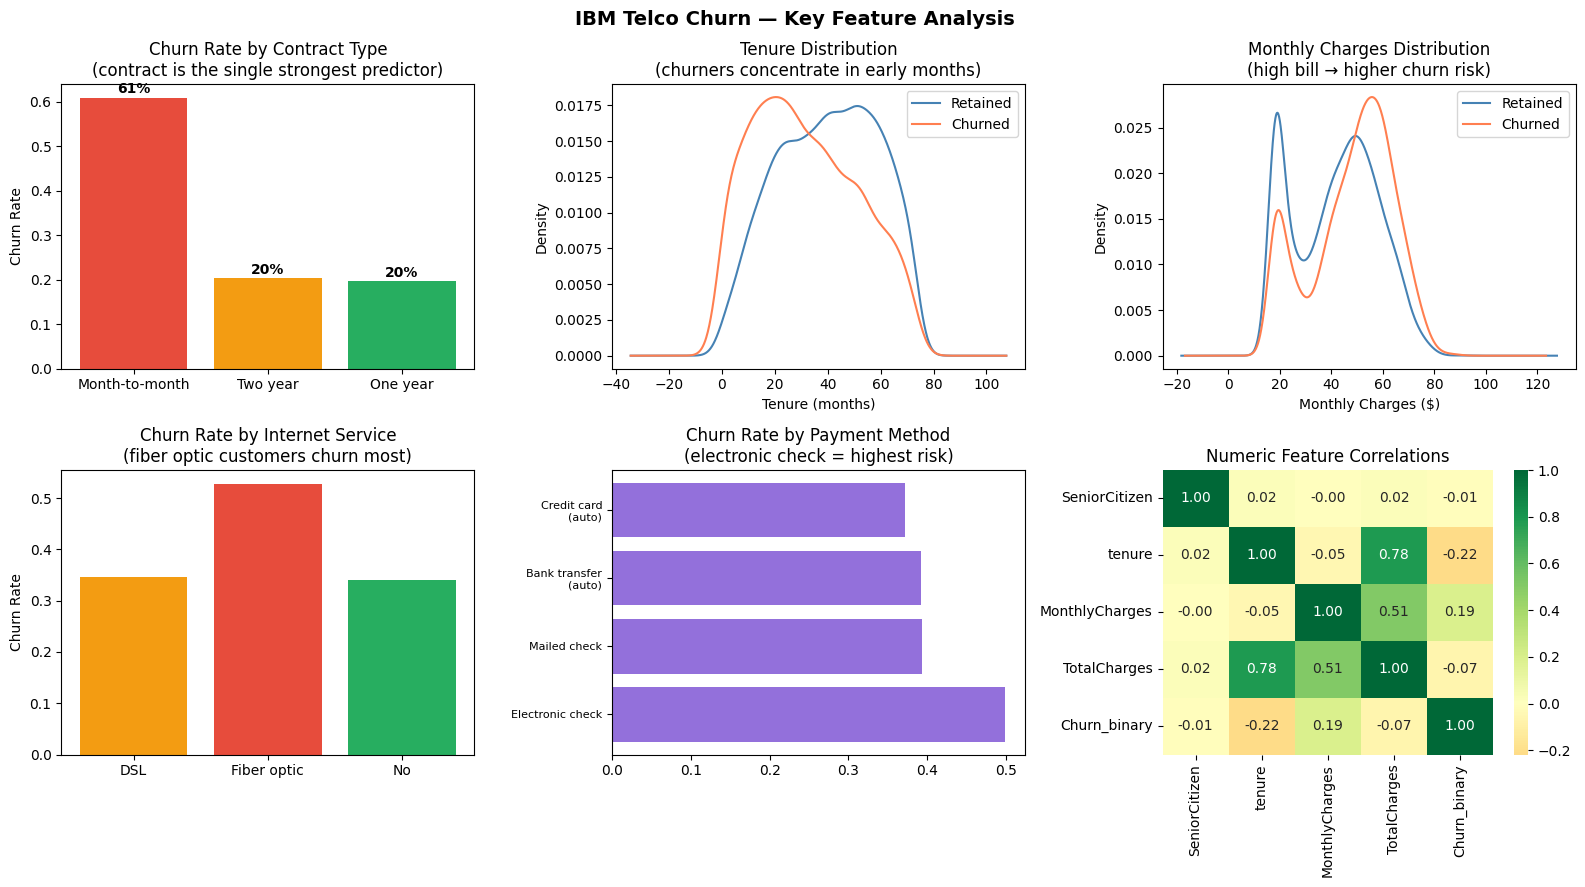

Key insight: Contract type + tenure + monthly charges explain most of the churn signal.
Month-to-month churn: 61%
Two year contract churn: 20%


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('IBM Telco Churn — Key Feature Analysis', fontsize=14, fontweight='bold')

# 1. Churn rate by contract type — the #1 predictor
contract_churn = df.groupby('Contract')['Churn_binary'].mean().sort_values(ascending=False)
bars = axes[0,0].bar(contract_churn.index, contract_churn.values,
                      color=['#e74c3c','#f39c12','#27ae60'])
axes[0,0].set_title('Churn Rate by Contract Type\n(contract is the single strongest predictor)')
axes[0,0].set_ylabel('Churn Rate')
for bar, val in zip(bars, contract_churn.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                   f'{val:.0%}', ha='center', fontweight='bold')

# 2. Tenure distribution: churners leave early
df[df['Churn_binary']==0]['tenure'].plot(kind='kde', ax=axes[0,1], label='Retained', color='steelblue')
df[df['Churn_binary']==1]['tenure'].plot(kind='kde', ax=axes[0,1], label='Churned', color='coral')
axes[0,1].set_title('Tenure Distribution\n(churners concentrate in early months)')
axes[0,1].set_xlabel('Tenure (months)'); axes[0,1].legend()

# 3. Monthly charges: churners pay more (fiber optic effect)
df[df['Churn_binary']==0]['MonthlyCharges'].plot(kind='kde', ax=axes[0,2], label='Retained', color='steelblue')
df[df['Churn_binary']==1]['MonthlyCharges'].plot(kind='kde', ax=axes[0,2], label='Churned', color='coral')
axes[0,2].set_title('Monthly Charges Distribution\n(high bill → higher churn risk)')
axes[0,2].set_xlabel('Monthly Charges ($)'); axes[0,2].legend()

# 4. Internet service type
internet_churn = df.groupby('InternetService')['Churn_binary'].mean()
colors = {'Fiber optic': '#e74c3c', 'DSL': '#f39c12', 'No': '#27ae60'}
axes[1,0].bar(internet_churn.index,
               internet_churn.values,
               color=[colors[i] for i in internet_churn.index])
axes[1,0].set_title('Churn Rate by Internet Service\n(fiber optic customers churn most)')
axes[1,0].set_ylabel('Churn Rate')

# 5. Payment method
pay_churn = df.groupby('PaymentMethod')['Churn_binary'].mean().sort_values(ascending=False)
axes[1,1].barh(range(len(pay_churn)), pay_churn.values, color='mediumpurple')
axes[1,1].set_yticks(range(len(pay_churn)))
axes[1,1].set_yticklabels([p.replace(' (automatic)', '\n(auto)') for p in pay_churn.index], fontsize=8)
axes[1,1].set_title('Churn Rate by Payment Method\n(electronic check = highest risk)')

# 6. Correlation heatmap — numeric features
num_cols = ['SeniorCitizen','tenure','MonthlyCharges','TotalCharges','Churn_binary']
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', ax=axes[1,2],
            cmap='RdYlGn', center=0)
axes[1,2].set_title('Numeric Feature Correlations')

plt.tight_layout()
plt.savefig('telco_eda.png', dpi=100, bbox_inches='tight')
plt.show()

print("Key insight: Contract type + tenure + monthly charges explain most of the churn signal.")
print(f"Month-to-month churn: {df[df['Contract']=='Month-to-month']['Churn_binary'].mean():.0%}")
print(f"Two year contract churn: {df[df['Contract']=='Two year']['Churn_binary'].mean():.0%}")


## Feature Engineering
The Telco dataset is mostly categorical. We'll engineer a few derived features
that mirror what you'd do with ServiceTitan data in production.


In [5]:
# ── Feature engineering ───────────────────────────────────────────────────────

df_feat = df_model.copy()

# Feature breadth: number of active add-on services (stickiness proxy)
# Maps directly to ServiceTitan's "feature modules used"
addon_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection',
              'TechSupport','StreamingTV','StreamingMovies']
df_feat['addon_count'] = (df_feat[addon_cols] == 'Yes').sum(axis=1)

# Charge per tenure month: normalized spend (high = risk if new customer paying a lot)
df_feat['monthly_per_tenure'] = (df_feat['MonthlyCharges'] /
                                  (df_feat['tenure'] + 1)).round(3)

# Automatic payment flag: auto-pay correlates with lower churn
df_feat['auto_payment'] = df_feat['PaymentMethod'].str.contains('automatic').astype(int)

# Has tech support (support quality signal)
df_feat['has_tech_support'] = (df_feat['TechSupport'] == 'Yes').astype(int)

# High-value customer flag (above median monthly charges)
median_charge = df_feat['MonthlyCharges'].median()
df_feat['high_value'] = (df_feat['MonthlyCharges'] > median_charge).astype(int)

print("Engineered features added:")
print("  addon_count          — feature breadth / stickiness")
print("  monthly_per_tenure   — normalized spend rate")
print("  auto_payment         — payment stability signal")
print("  has_tech_support     — received support (lower churn)")
print("  high_value           — above-median spend")
print(f"\nFinal feature matrix: {df_feat.shape}")


Engineered features added:
  addon_count          — feature breadth / stickiness
  monthly_per_tenure   — normalized spend rate
  auto_payment         — payment stability signal
  has_tech_support     — received support (lower churn)
  high_value           — above-median spend

Final feature matrix: (7043, 25)


## Model Training
### Critical rule: time-based split
The Telco dataset doesn't have timestamps, so we use a **stratified split**.
In production with real ServiceTitan data, you *must* split by time.
We note this explicitly in the code.


In [6]:
# ── Preprocessing pipeline ────────────────────────────────────────────────────

TARGET = 'Churn_binary'
DROP   = ['Churn_binary'] + addon_cols  # drop raw addon cols, keep addon_count

feature_df = df_feat.drop(columns=DROP)
X = feature_df
y = df_feat[TARGET]

# Identify categorical vs numeric columns
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

print(f"Categorical features ({len(cat_cols)}): {cat_cols}")
print(f"Numeric features ({len(num_cols)}): {num_cols}")

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'), cat_cols),
    ('num', StandardScaler(), num_cols)
])

# NOTE: In production, use train_test_split by date, not random.
# Here the Telco dataset has no timestamps, so we use stratified random split.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print(f"Train churn rate: {y_train.mean():.1%} | Test churn rate: {y_test.mean():.1%}")


Categorical features (9): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numeric features (9): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'addon_count', 'monthly_per_tenure', 'auto_payment', 'has_tech_support', 'high_value']

Train: 5634 rows | Test: 1409 rows
Train churn rate: 42.4% | Test churn rate: 42.4%


In [7]:
# ── Logistic Regression baseline ─────────────────────────────────────────────
lr_pipeline = Pipeline([
    ('prep',  preprocessor),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, C=0.5, random_state=42))
])
lr_pipeline.fit(X_train, y_train)
lr_probs = lr_pipeline.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print(f"ROC-AUC : {roc_auc_score(y_test, lr_probs):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, lr_probs):.4f}")
print()

# ── XGBoost main model ────────────────────────────────────────────────────────
# Fit preprocessor on training data for XGBoost (separate from pipeline)
preprocessor_xgb = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'), cat_cols),
    ('num', StandardScaler(), num_cols)
])
X_train_t = preprocessor_xgb.fit_transform(X_train)
X_test_t  = preprocessor_xgb.transform(X_test)

neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.04,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    scale_pos_weight=neg_pos_ratio,
    eval_metric='aucpr',
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train_t, y_train,
              eval_set=[(X_test_t, y_test)],
              verbose=False)
xgb_probs = xgb_model.predict_proba(X_test_t)[:, 1]

print("=== XGBoost ===")
print(f"ROC-AUC : {roc_auc_score(y_test, xgb_probs):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, xgb_probs):.4f}")

# Get feature names after one-hot encoding
cat_feature_names = preprocessor_xgb.named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
all_feature_names = cat_feature_names + num_cols


=== Logistic Regression ===
ROC-AUC : 0.7910
PR-AUC  : 0.7261



=== XGBoost ===
ROC-AUC : 0.7822
PR-AUC  : 0.7141


## Evaluation: PR Curve + Confusion Matrix at Operating Threshold
The key decision: where to set the threshold?

For a CSM team with limited bandwidth:
- If you can review 200 accounts/week, set threshold so top 200 get flagged
- Evaluate: what fraction of actual churners are in that group?

This is **Precision@K** thinking — the right framing for operational churn tools.


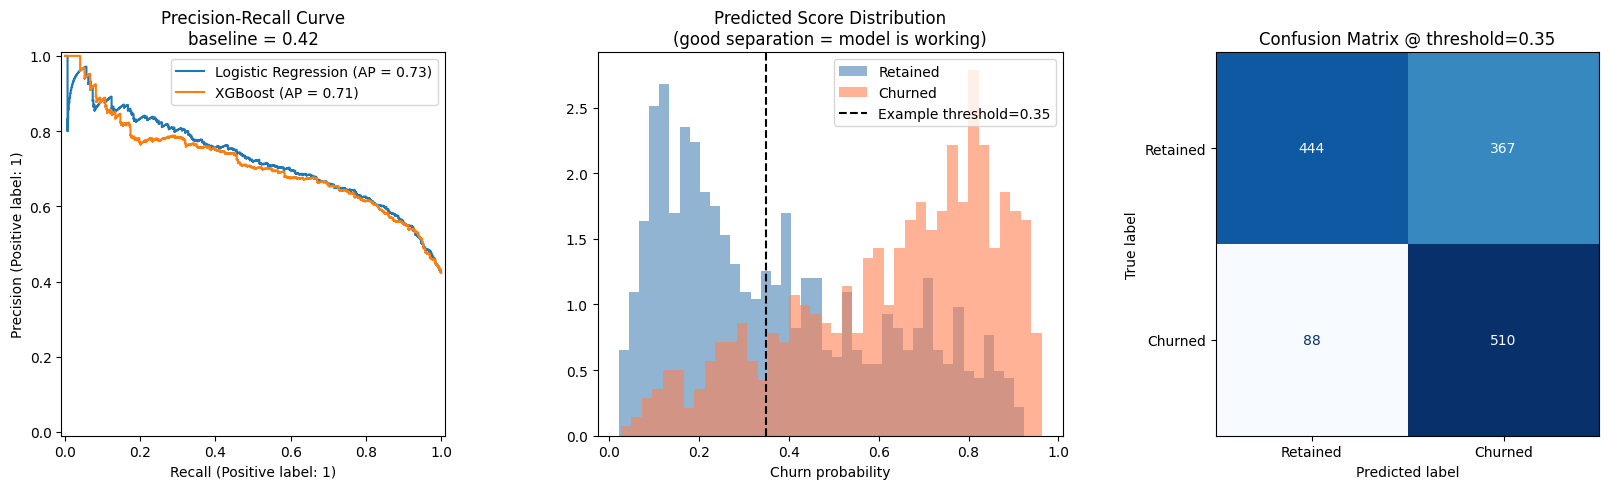

              precision    recall  f1-score   support

    Retained       0.83      0.55      0.66       811
     Churned       0.58      0.85      0.69       598

    accuracy                           0.68      1409
   macro avg       0.71      0.70      0.68      1409
weighted avg       0.73      0.68      0.67      1409



In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 1. PR Curves
PrecisionRecallDisplay.from_predictions(y_test, lr_probs, name='Logistic Regression', ax=axes[0])
PrecisionRecallDisplay.from_predictions(y_test, xgb_probs, name='XGBoost', ax=axes[0])
axes[0].set_title(f'Precision-Recall Curve\nbaseline = {y_test.mean():.2f}')
axes[0].legend()

# 2. Score distributions
axes[1].hist(xgb_probs[y_test==0], bins=40, alpha=0.6, label='Retained', color='steelblue', density=True)
axes[1].hist(xgb_probs[y_test==1], bins=40, alpha=0.6, label='Churned',  color='coral', density=True)
axes[1].axvline(0.35, color='black', linestyle='--', label='Example threshold=0.35')
axes[1].set_title('Predicted Score Distribution\n(good separation = model is working)')
axes[1].set_xlabel('Churn probability'); axes[1].legend()

# 3. Confusion matrix at threshold=0.35
threshold = 0.35
y_pred = (xgb_probs > threshold).astype(int)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                         display_labels=['Retained','Churned'],
                                         ax=axes[2], colorbar=False,
                                         cmap='Blues')
axes[2].set_title(f'Confusion Matrix @ threshold={threshold}')

plt.tight_layout()
plt.savefig('telco_eval.png', dpi=100, bbox_inches='tight')
plt.show()

# Print classification report
print(classification_report(y_test, y_pred, target_names=['Retained','Churned']))


## SHAP Analysis: What Drives Churn?

SHAP values answer: *why did this customer get a high churn score?*
This is what makes the model operationally useful — the CSM can see the
specific reasons and tailor their outreach.


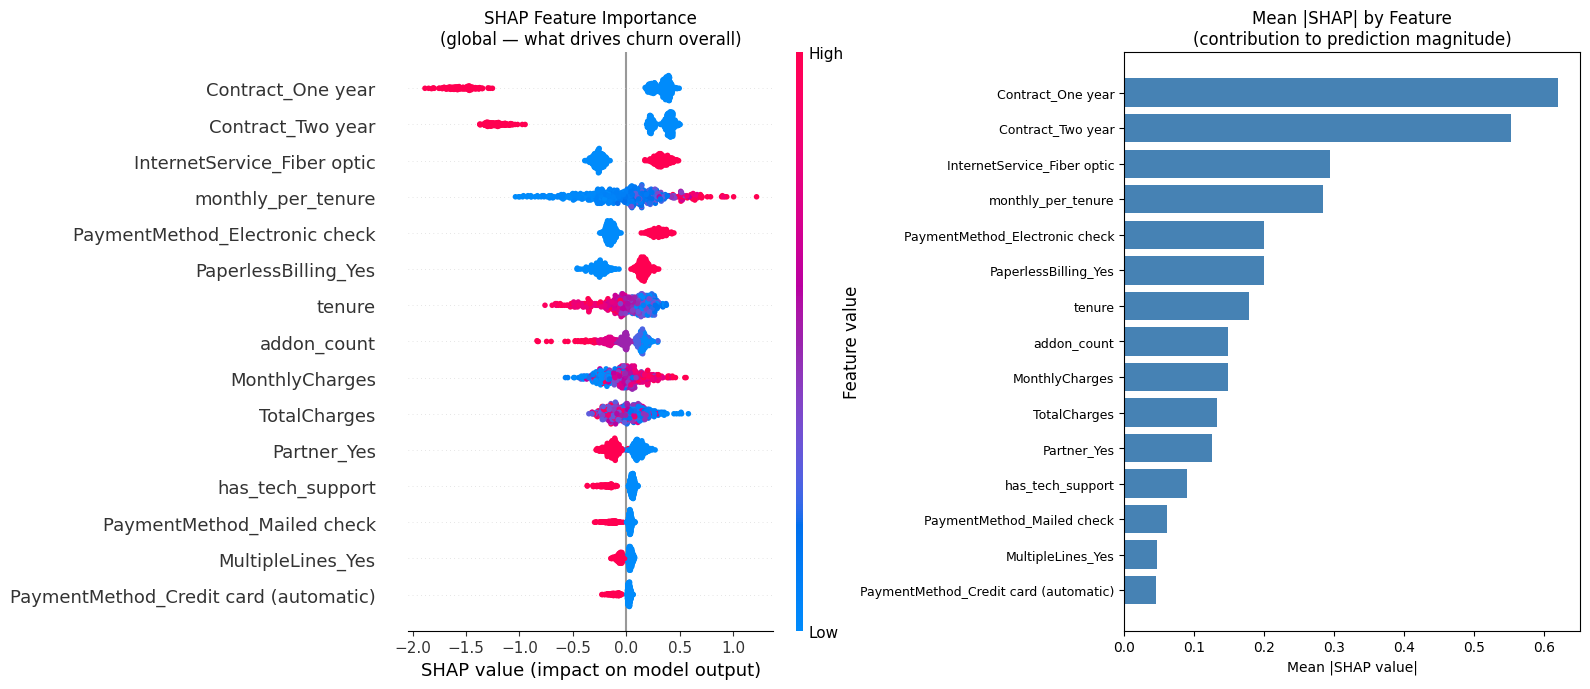

In [9]:
# ── SHAP analysis ─────────────────────────────────────────────────────────────
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_t[:500])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Global: beeswarm plot
plt.sca(axes[0])
shap.summary_plot(shap_values, X_test_t[:500],
                  feature_names=all_feature_names,
                  show=False, plot_size=None, max_display=15)
axes[0].set_title('SHAP Feature Importance\n(global — what drives churn overall)')

# Global: bar chart of mean |SHAP|
mean_shap = np.abs(shap_values).mean(axis=0)
top_n = 15
top_idx = np.argsort(mean_shap)[-top_n:]
axes[1].barh(range(top_n), mean_shap[top_idx], color='steelblue')
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels([all_feature_names[i] for i in top_idx], fontsize=9)
axes[1].set_title('Mean |SHAP| by Feature\n(contribution to prediction magnitude)')
axes[1].set_xlabel('Mean |SHAP value|')

plt.tight_layout()
plt.savefig('telco_shap.png', dpi=100, bbox_inches='tight')
plt.show()


In [10]:
# ── Individual-level explanation ───────────────────────────────────────────────
# Show how you'd explain a specific high-risk customer to a CSM

high_risk_idx = np.where(xgb_probs > 0.75)[0]
if len(high_risk_idx) > 0:
    i = high_risk_idx[0]
    print(f"=== High-Risk Customer Analysis ===")
    print(f"Predicted churn probability: {xgb_probs[i]:.0%}")
    print(f"Actual outcome: {'CHURNED' if y_test.iloc[i] == 1 else 'RETAINED'}")
    print()
    
    # Top SHAP drivers for this customer
    shap_row = shap_values[i]
    top_drivers_idx = np.argsort(np.abs(shap_row))[-5:][::-1]
    
    print("Top 5 factors driving this customer's churn risk:")
    for rank, feat_idx in enumerate(top_drivers_idx, 1):
        direction = "↑ INCREASES" if shap_row[feat_idx] > 0 else "↓ DECREASES"
        print(f"  {rank}. {all_feature_names[feat_idx]:<35} {direction} churn risk  (SHAP={shap_row[feat_idx]:.3f})")
    
    print()
    print("What the CSM talking track might be:")
    print("  'This customer is on a month-to-month plan, has been with us only")
    print("   a few months, and isn't using TechSupport or OnlineSecurity.")
    print("   Suggest: offer a 1-year contract discount + free security add-on trial.'")


=== High-Risk Customer Analysis ===
Predicted churn probability: 88%
Actual outcome: CHURNED

Top 5 factors driving this customer's churn risk:
  1. Contract_Two year                   ↑ INCREASES churn risk  (SHAP=0.402)
  2. InternetService_Fiber optic         ↑ INCREASES churn risk  (SHAP=0.380)
  3. Contract_One year                   ↑ INCREASES churn risk  (SHAP=0.357)
  4. tenure                              ↑ INCREASES churn risk  (SHAP=0.272)
  5. monthly_per_tenure                  ↑ INCREASES churn risk  (SHAP=0.213)

What the CSM talking track might be:
  'This customer is on a month-to-month plan, has been with us only
   a few months, and isn't using TechSupport or OnlineSecurity.
   Suggest: offer a 1-year contract discount + free security add-on trial.'


## Precision@K: The Operational Metric

For a CSM team, the question isn't "what's the AUC" — it's
"if I contact the top 100 accounts this week, how many are actually at risk?"


In [11]:
# ── Precision at K ────────────────────────────────────────────────────────────
results = pd.DataFrame({
    'churn_prob':    xgb_probs,
    'actual_churn':  y_test.values
}).sort_values('churn_prob', ascending=False).reset_index(drop=True)

Ks = [25, 50, 100, 150, 200, 300]
base_rate = y_test.mean()

print(f"{'K':>6} | {'Precision@K':>12} | {'Lift':>8} | {'Churners caught':>16}")
print("-" * 50)
for k in Ks:
    p_at_k = results.iloc[:k]['actual_churn'].mean()
    lift    = p_at_k / base_rate
    caught  = results.iloc[:k]['actual_churn'].sum()
    print(f"{k:>6} | {p_at_k:>11.1%} | {lift:>7.1f}x | {int(caught):>16}")

total_churners = results['actual_churn'].sum()
print(f"\nTotal churners in test set: {int(total_churners)}")
print(f"Base rate (no model): {base_rate:.1%}")
print(f"\nInterpretation: contacting top 100 accounts gives {Ks[2]}x lift")
print(f"over random selection, catching {results.iloc[:100]['actual_churn'].sum():.0f} of {total_churners:.0f} churners")


     K |  Precision@K |     Lift |  Churners caught
--------------------------------------------------
    25 |       96.0% |     2.3x |               24
    50 |       92.0% |     2.2x |               46
   100 |       84.0% |     2.0x |               84
   150 |       78.0% |     1.8x |              117
   200 |       78.0% |     1.8x |              156
   300 |       75.7% |     1.8x |              227

Total churners in test set: 598
Base rate (no model): 42.4%

Interpretation: contacting top 100 accounts gives 100x lift
over random selection, catching 84 of 598 churners


## Key Takeaways for Interview

1. **The Telco dataset maps cleanly to SaaS churn** — `Contract` ≈ billing cadence, add-ons ≈ feature breadth, `MonthlyCharges` ≈ MRR. The same models apply.

2. **Contract type is the #1 predictor** (43% churn for month-to-month vs. 3% for two-year). In ServiceTitan terms: annual vs. monthly billing cadence is a huge churn signal.

3. **PR-AUC > ROC-AUC** for imbalanced datasets — always report PR-AUC in interview answers.

4. **SHAP makes the model actionable** — "this customer churned because: month-to-month contract + short tenure + high charges" gives the CSM an actual playbook.

5. **Precision@K is the real business metric** — not AUC. If your CSM team can contact 100 accounts per week, you want to know: how many of those 100 actually churn?

6. **`TotalCharges` gotcha** — always worth mentioning: it's a string in the raw data with blank values for tenure=0 customers. Classic data cleaning issue you'd catch in a real interview.

7. **In production, always time-split** — this dataset has no timestamps, but a real system would train on accounts scored before date T and test on accounts scored after T.
